# Lesson 03: Computer Vision with PyTorch

This notebook covers:
- Loading image datasets with torchvision
- Working with Fashion-MNIST dataset
- Building neural networks for image classification
- Convolutional Neural Networks (CNNs)
- Model evaluation and visualization
- Saving and loading models

## Setup and Imports

In [3]:
# Import PyTorch core libraries
import torch
from torch import nn  # Neural network building blocks

# Import Torchvision - PyTorch's computer vision library
import torchvision  # Contains datasets, models, and transforms for computer vision
from torchvision import datasets  # Pre-built datasets (MNIST, CIFAR, etc.)
from torchvision import transforms  # Image transformations (resize, normalize, etc.)
from torchvision.transforms import ToTensor  # Convert PIL images to tensors

# Import utility libraries
import numpy as np
import matplotlib.pyplot as plt
import time

# Display versions for debugging
print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu121
0.20.1+cu121


In [4]:
# Setup device-agnostic code
# Automatically use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device} is in use")

cuda is in use


## Part 1: Loading Fashion-MNIST Dataset

Fashion-MNIST is a dataset of 70,000 grayscale images (28x28 pixels) of clothing items in 10 categories.

In [5]:
# Download and setup training data
train_data = datasets.FashionMNIST(
    root="data",  # Directory where data will be stored
    train=True,  # Get training split (60,000 images)
    download=True,  # Download if not already present
    transform=ToTensor(),  # Convert PIL images to PyTorch tensors
    target_transform=None  # Optional: transform labels (we don't need this)
)

# Download and setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,  # Get test split (10,000 images)
    download=True,
    transform=ToTensor()
)

In [6]:
# Check dataset sizes
# Training: 60,000 images, Testing: 10,000 images
len(train_data), len(test_data)

(60000, 10000)

In [7]:
# Get a single sample from the dataset
# Datasets are indexable like lists
image, label = train_data[0]
# image, label

In [8]:
# Get class names from the dataset
# Fashion-MNIST has 10 classes of clothing items
class_names = train_data.classes
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [9]:
# Display information about the first image
# Shape: (1, 28, 28) = (channels, height, width)
# 1 channel = grayscale, 28x28 pixels
print(f"Image's shape: {image.shape}") 
print(f"Image's label: {class_names[label]}")

Image's shape: torch.Size([1, 28, 28])
Image's label: Ankle boot


## Visualizing the Dataset

In [10]:
# Visualize a random image from the dataset
torch.manual_seed(int(time.time())) 
# Generate random index within dataset range
random_index = torch.randint(0, len(train_data), size=[1]).item()

# Get the image and label at that index
image, label = train_data[random_index]

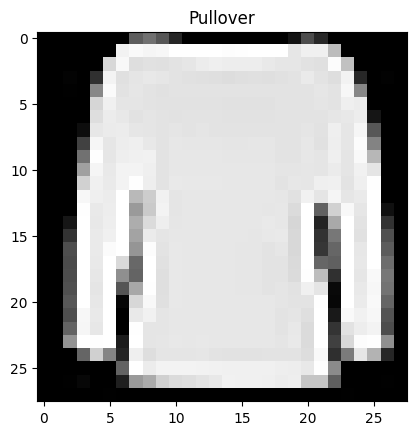

In [11]:
# Plot the image
plt.title(class_names[label])
# squeeze() removes the channel dimension for plotting (28, 28) instead of (1, 28, 28)
plt.imshow(image.squeeze(), cmap="gray")
plt.show()

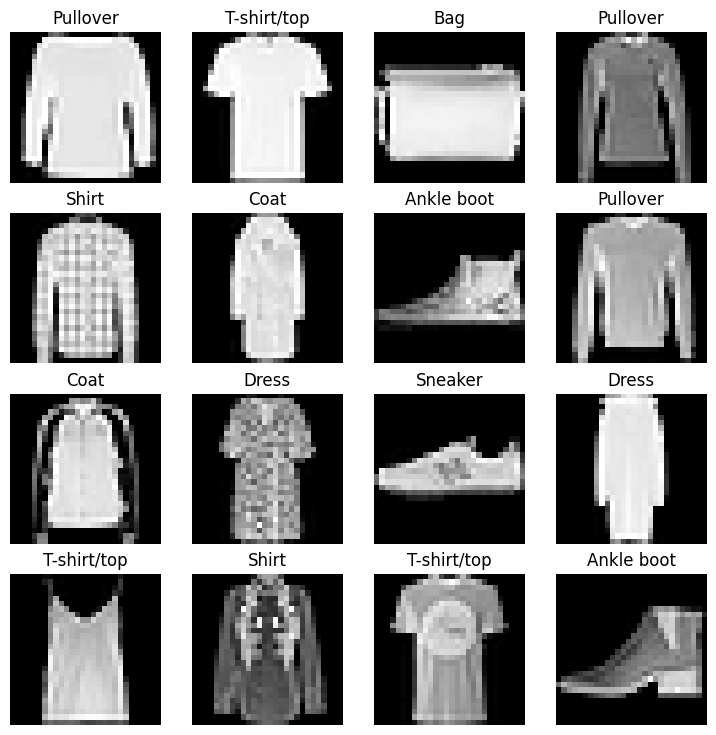

In [12]:
# Plot multiple random images in a grid
# This gives us a better sense of the dataset variety
torch.manual_seed(int(time.time()))
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

# Create a 4x4 grid of images
for i in range(1, rows * cols + 1):
    # Get random sample
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    
    # Add subplot to figure
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)  # Hide axes for cleaner visualization

## Part 2: Creating DataLoaders

DataLoaders help us efficiently iterate through datasets in batches during training.

In [13]:
# Import DataLoader for batch processing
from torch.utils.data import DataLoader

In [14]:
# Set batch size hyperparameter
# Batch size: number of samples processed before updating model parameters
# 32 is a common default choice (trade-off between speed and memory)
BATCH_SIZE = 32

# Create DataLoader for training data
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True  # Shuffle data each epoch to prevent learning order
)

# Create DataLoader for test data
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False  # Don't shuffle test data (order doesn't matter)
)

In [15]:
# Inspect the DataLoaders
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
# Number of batches = total samples / batch size
# 60,000 / 32 = 1,875 batches for training
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
# 10,000 / 32 = 313 batches for testing (rounded up)
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x00000156FEE95210>, <torch.utils.data.dataloader.DataLoader object at 0x000001568616B610>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [16]:
# Get one batch from the training DataLoader
# next(iter()) gets the first batch
train_features_batch, train_labels_batch = next(iter(train_dataloader))

# Check batch shapes
# Features: (32, 1, 28, 28) = (batch_size, channels, height, width)
# Labels: (32,) = batch of 32 labels
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 7, label size: torch.Size([])


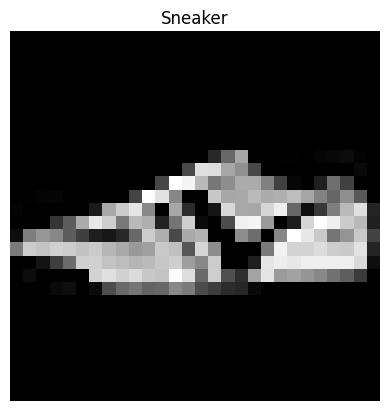

In [17]:
# Visualize a sample from the batch
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off")

print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

## Part 3: Building Model V0 - Simple Linear Network

In [18]:
# Demonstrate the Flatten layer
# Flatten converts 2D images into 1D vectors for linear layers
flatten_model = nn.Flatten()

# Get a sample image: shape (1, 28, 28)
x = train_features_batch[0]
print(x.shape)

# Flatten the sample: shape becomes (784,)
# 28 * 28 = 784 pixels
output = flatten_model(x)
print(output.shape)

torch.Size([1, 28, 28])
torch.Size([1, 784])


In [19]:
# Define a simple baseline model with only linear layers
# This is a basic feedforward neural network (no convolutions)
class Fashion_MINST_Model_V0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        """
        Simple neural network for image classification.
        
        Args:
            input_shape: Number of input features (784 for flattened 28x28 image)
            hidden_units: Number of neurons in hidden layer
            output_shape: Number of output classes (10 for Fashion-MNIST)
        """
        super().__init__()

        # Build network architecture
        self.layer_stack = nn.Sequential(
            nn.Flatten(),  # Flatten 2D image (1, 28, 28) -> 1D vector (784)
            # Input layer -> Hidden layer
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            # Hidden layer -> Output layer
            # Output has 10 neurons (one per class)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        """Forward pass through the network."""
        return self.layer_stack(x)

In [20]:
# Create an instance of the model
torch.manual_seed(42)

model_0 = Fashion_MINST_Model_V0(
    input_shape=784,  # 28 * 28 = 784 pixels
    hidden_units=10,  # Small hidden layer (we'll increase this later)
    output_shape=len(class_names)  # 10 classes
).to("cpu")  # Keep on CPU for now

In [21]:
# Test the model with dummy input
# Create a random image: (batch=1, channels=1, height=28, width=28)
dummy_x = torch.rand([1, 1, 28, 28])

# Pass through model - should output 10 values (one per class)
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

## Setup Loss Function and Optimizer

In [22]:
# Download helper functions if not already present
import requests
from pathlib import Path 

if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    # Note: need the "raw" GitHub URL
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

helper_functions.py already exists, skipping download


In [23]:
# Import accuracy metric from helper functions
# Alternative: torchmetrics.Accuracy(task='multiclass', num_classes=len(class_names))
from helper_functions import accuracy_fn

# Setup loss function for multi-class classification
# CrossEntropyLoss combines LogSoftmax + NLLLoss
# Also called "criterion" or "cost function" in some contexts
loss_fn = nn.CrossEntropyLoss()

# Setup optimizer - Stochastic Gradient Descent
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

## Training Utilities

In [24]:
# Helper function to track training time
from timeit import default_timer as timer 

def print_train_time(start: float, end: float, device: torch.device = None):
    """
    Prints the difference between start and end time.

    Args:
        start (float): Start time of computation (from timer())
        end (float): End time of computation
        device: Device computation ran on (CPU or CUDA)

    Returns:
        float: Total time in seconds
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

## Training Model V0

In [25]:
# Import tqdm for progress bars during training
from tqdm.auto import tqdm

# Set random seed and start timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Number of epochs to train
# Keeping small (3) for faster experimentation
epochs = 3

# Training and testing loop
for epoch in tqdm(range(epochs)):

    print(f"Epoch: {epoch+1}\n-------")
    
    ### TRAINING PHASE ###
    train_loss = 0

    # Loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):

        model_0.train()  # Set model to training mode

        # 1. Forward pass - get predictions
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss  # Accumulate loss for epoch average

        # 3. Zero gradients from previous batch
        optimizer.zero_grad()

        # 4. Backpropagation - compute gradients
        loss.backward()

        # 5. Update parameters
        optimizer.step()

        # Print progress every 400 batches
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Calculate average training loss per batch
    train_loss /= len(train_dataloader)

    ### TESTING PHASE ###
    test_loss, test_acc = 0, 0
    model_0.eval()  # Set model to evaluation mode

    with torch.inference_mode():  # Disable gradient tracking for testing

        for X_test, y_test in test_dataloader:

            # 1. Forward pass
            test_pred = model_0(X_test)

            # 2. Calculate loss (accumulate)
            test_loss += loss_fn(test_pred, y_test)

            # 3. Calculate accuracy
            # argmax(dim=1) gets the class with highest probability
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

        # Calculate average test loss and accuracy per batch
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    # Print epoch results
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate and display total training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(
    start=train_time_start_on_cpu, 
    end=train_time_end_on_cpu,
    device=str(next(model_0.parameters()).device)
)

c:\Users\krzys\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 1/3 [00:08<00:16,  8.20s/it]


Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 67%|██████▋   | 2/3 [00:16<00:08,  8.13s/it]


Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 3
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 3/3 [00:24<00:00,  8.13s/it]


Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu: 24.381 seconds


## Model Evaluation Function

In [26]:
# Function to evaluate model on test data
def eval_model(
        model: torch.nn.Module,
        data_loader: torch.utils.data.DataLoader,
        loss_fn: torch.nn.Module,
        accuracy_fn):
    """
    Evaluates a model on a dataset.
    
    Returns:
        Dictionary with model name, loss, and accuracy
    """
    
    loss, acc = 0, 0
    model.eval()
    
    with torch.inference_mode():

        for X, y in tqdm(data_loader):

            # Make predictions
            y_pred = model(X)

            # Accumulate loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Calculate average loss and accuracy per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss.item(),
        "model_acc": acc
    }

In [27]:
# Evaluate model 0 on test dataset
model_0_results = eval_model(
    model=model_0, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)
model_0_results

100%|██████████| 313/313 [00:00<00:00, 316.40it/s]


{'model_name': 'Fashion_MINST_Model_V0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## Setting up GPU Training

In [28]:
# Check which device is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [29]:
# Check GPU information (if available)
# This command only works in Jupyter/Colab with NVIDIA GPUs
!nvidia-smi

Tue Apr 14 18:05:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P0             27W /  100W |       0MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Part 4: Model V1 - Adding Non-linearity (ReLU)

In [30]:
# Improved model with ReLU activation functions
# ReLU adds non-linearity, allowing the model to learn more complex patterns
class Fashion_MINST_Model_V1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),  # Flatten 2D image to 1D
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),  # Non-linear activation - KEY DIFFERENCE from V0!
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()  # Another ReLU activation
        )

    def forward(self, x):
        return self.layer_stack(x)

In [31]:
# Create model V1 instance and move to device (GPU if available)
torch.manual_seed(42)

model_1 = Fashion_MINST_Model_V1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)  # Move to GPU if available

In [32]:
# Setup loss and optimizer for model V1
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.1
)

## Refactored Training Functions

In [33]:
# Create reusable training and testing functions

def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device
):
    """
    Performs a single training epoch.
    """
    train_loss, train_acc = 0, 0
    model.to(device)
    model.train()

    # Loop through training batches
    for batch, (X, y) in enumerate(data_loader):

        # Move data to device (GPU if available)
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss and accuracy
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate average loss and accuracy
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


def test_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device
):
    """
    Performs evaluation on test data.
    """
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()

    with torch.inference_mode():

        for X_test, y_test in data_loader:

            # Move data to device
            X_test, y_test = X_test.to(device), y_test.to(device)

            # 1. Forward pass
            test_pred = model(X_test)

            # 2. Calculate loss
            test_loss += loss_fn(test_pred, y_test)

            # 3. Calculate accuracy
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

        # Calculate averages
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

## Training Model V1

In [34]:
# Train model V1 using the refactored functions
torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

# Training loop using helper functions
for epoch in tqdm(range(epochs)):
    
    print(f"Epoch: {epoch+1}\n-------")

    # Train for one epoch
    train_step(
        model=model_1,
        data_loader=train_dataloader,
        loss_fn=loss_fn, 
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    
    # Evaluate on test set
    test_step(
        data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_1 = print_train_time(
    start=train_time_start_on_cpu, 
    end=train_time_end_on_cpu,
    device=str(next(model_1.parameters()).device)
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1
-------
Train loss: 1.09199 | Train accuracy: 61.34%


 33%|███▎      | 1/3 [00:10<00:20, 10.20s/it]

Test loss: 0.95636 | Test accuracy: 65.00%

Epoch: 2
-------
Train loss: 0.78101 | Train accuracy: 71.93%


 67%|██████▋   | 2/3 [00:21<00:10, 10.73s/it]

Test loss: 0.72227 | Test accuracy: 73.91%

Epoch: 3
-------
Train loss: 0.67027 | Train accuracy: 75.94%


100%|██████████| 3/3 [00:33<00:00, 11.01s/it]

Test loss: 0.68500 | Test accuracy: 75.02%

Train time on cuda:0: 33.039 seconds


In [35]:
# Updated eval function that handles device placement
def eval_model(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device
):
    """
    Evaluates model with proper device handling.
    """
    loss, acc = 0, 0
    model.eval()
    
    with torch.inference_mode():

        for X, y in tqdm(data_loader):

            # Move data to same device as model
            X, y = X.to(device), y.to(device)

            # Make predictions
            y_pred = model(X)

            # Accumulate loss and accuracy
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Calculate averages
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss.item(),
        "model_acc": acc
    }

In [36]:
# Evaluate model V1
model_1_results = eval_model(
    model=model_1, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)
model_1_results

100%|██████████| 313/313 [00:01<00:00, 219.67it/s]


{'model_name': 'Fashion_MINST_Model_V1',
 'model_loss': 0.6850008368492126,
 'model_acc': 75.01996805111821}

In [37]:
# Compare results from both models
# Model V1 (with ReLU) should perform better than V0 (without)
print(model_0_results)
print(model_1_results)

{'model_name': 'Fashion_MINST_Model_V0', 'model_loss': 0.47663894295692444, 'model_acc': 83.42651757188499}
{'model_name': 'Fashion_MINST_Model_V1', 'model_loss': 0.6850008368492126, 'model_acc': 75.01996805111821}


## Part 5: Model V2 - Convolutional Neural Network (CNN)

CNNs are specifically designed for image data and use convolutional layers to detect spatial patterns.

In [38]:
# Define a CNN architecture for Fashion-MNIST
class Fashion_MINST_Model_V2(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        """
        Convolutional Neural Network for image classification.
        
        Args:
            input_shape: Number of input channels (1 for grayscale)
            hidden_units: Number of hidden units in conv layers
            output_shape: Number of output classes (10)
        """
        super().__init__()
        
        # First convolutional block
        # Detects low-level features (edges, textures)
        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,  # 1 channel (grayscale)
                out_channels=hidden_units,  # Number of filters/kernels
                kernel_size=3,  # 3x3 filter window
                stride=1,  # Move filter 1 pixel at a time
                padding=1  # Add padding to maintain spatial dimensions
            ),
            nn.ReLU(),  # Non-linear activation
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            # MaxPool reduces spatial dimensions by taking max in each 2x2 window
            # Reduces 28x28 -> 14x14
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Second convolutional block
        # Detects higher-level features (patterns, shapes)
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            # MaxPool reduces 14x14 -> 7x7
            nn.MaxPool2d(2)
        )
        
        # Classifier head
        # Converts CNN features to class predictions
        self.classifier = nn.Sequential(
            nn.Flatten(),  # Flatten 3D tensor to 1D
            # Input size calculation:
            # After block_1: 28x28 -> 14x14 (MaxPool)
            # After block_2: 14x14 -> 7x7 (MaxPool)
            # With hidden_units filters: hidden_units * 7 * 7
            nn.Linear(
                in_features=hidden_units * 7 * 7,
                out_features=output_shape
            )
        )

    def forward(self, x: torch.Tensor):
        """
        Forward pass through the CNN.
        
        Flow: input -> conv_block_1 -> conv_block_2 -> classifier -> output
        """
        x = self.block_1(x)
        # print(x.shape)  # Uncomment to see shape changes
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

In [39]:
# Create CNN model instance
torch.manual_seed(42)

model_2 = Fashion_MINST_Model_V2(
    input_shape=1,  # Grayscale images
    hidden_units=10,  # Number of filters in conv layers
    output_shape=len(class_names)  # 10 classes
).to(device)

model_2

Fashion_MINST_Model_V2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## Testing CNN with Random Input

In [40]:
# Create random test image
rand_image_tensor = torch.randn(size=(1, 28, 28))

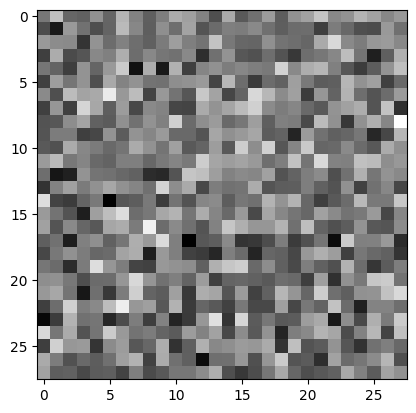

In [41]:
# Visualize random noise
plt.imshow(rand_image_tensor.squeeze(), cmap="grey")

In [42]:
# Test CNN with random input
# Need to add batch dimension: (1, 28, 28) -> (1, 1, 28, 28)
# unsqueeze(0) adds batch dimension at position 0
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], device='cuda:0', grad_fn=<AddmmBackward0>)

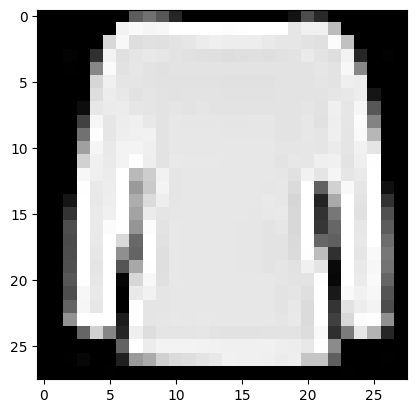

In [43]:
# Test with actual Fashion-MNIST image
plt.imshow(image.squeeze(), cmap="grey")

In [44]:
# Make prediction on real image
model_2(image.unsqueeze(0).to(device))

tensor([[ 0.0276, -0.0686,  0.0605, -0.0334, -0.0117,  0.0169,  0.0032, -0.0111,
          0.0214,  0.0073]], device='cuda:0', grad_fn=<AddmmBackward0>)

## Training Model V2 (CNN)

In [45]:
# Setup loss and optimizer for CNN
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_2.parameters(),
    lr=0.1
)

In [46]:
# Train the CNN model
torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

# Training loop
for epoch in tqdm(range(epochs)):
    
    print(f"Epoch: {epoch+1}\n-------")

    # Train
    train_step(
        model=model_2,
        data_loader=train_dataloader,
        loss_fn=loss_fn, 
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    
    # Test
    test_step(
        data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_2 = print_train_time(
    start=train_time_start_on_cpu, 
    end=train_time_end_on_cpu,
    device=str(next(model_2.parameters()).device)
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1
-------
Train loss: 0.60660 | Train accuracy: 78.06%


 33%|███▎      | 1/3 [00:15<00:30, 15.44s/it]

Test loss: 0.40012 | Test accuracy: 86.10%

Epoch: 2
-------
Train loss: 0.36017 | Train accuracy: 87.00%


 67%|██████▋   | 2/3 [00:30<00:15, 15.05s/it]

Test loss: 0.34132 | Test accuracy: 87.69%

Epoch: 3
-------
Train loss: 0.32443 | Train accuracy: 88.28%


100%|██████████| 3/3 [00:44<00:00, 14.81s/it]

Test loss: 0.32652 | Test accuracy: 88.15%

Train time on cuda:0: 44.433 seconds


In [47]:
# Evaluate CNN model
model_2_results = eval_model(
    model=model_2, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)
model_2_results

100%|██████████| 313/313 [00:01<00:00, 186.69it/s]


{'model_name': 'Fashion_MINST_Model_V2',
 'model_loss': 0.32652345299720764,
 'model_acc': 88.14896166134186}

In [48]:
# Compare all three models
# CNN (model_2) should significantly outperform the linear models
print(model_0_results)
print(model_1_results)
print(model_2_results)

{'model_name': 'Fashion_MINST_Model_V0', 'model_loss': 0.47663894295692444, 'model_acc': 83.42651757188499}
{'model_name': 'Fashion_MINST_Model_V1', 'model_loss': 0.6850008368492126, 'model_acc': 75.01996805111821}
{'model_name': 'Fashion_MINST_Model_V2', 'model_loss': 0.32652345299720764, 'model_acc': 88.14896166134186}


## Model Comparison Visualization

In [49]:
import pandas as pd

In [50]:
# Create comparison DataFrame
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,Fashion_MINST_Model_V0,0.476639,83.426518
1,Fashion_MINST_Model_V1,0.685001,75.019968
2,Fashion_MINST_Model_V2,0.326523,88.148962


In [51]:
# Add training times to comparison
compare_results["training_time"] = [
    total_train_time_model_0,
    total_train_time_model_1,
    total_train_time_model_2
]
compare_results

,model_name,model_loss,model_acc,training_time
0,Fashion_MINST_Model_V0,0.476639,83.426518,24.380512
1,Fashion_MINST_Model_V1,0.685001,75.019968,33.038850
2,Fashion_MINST_Model_V2,0.326523,88.148962,44.432589


Text(0, 0.5, 'model')

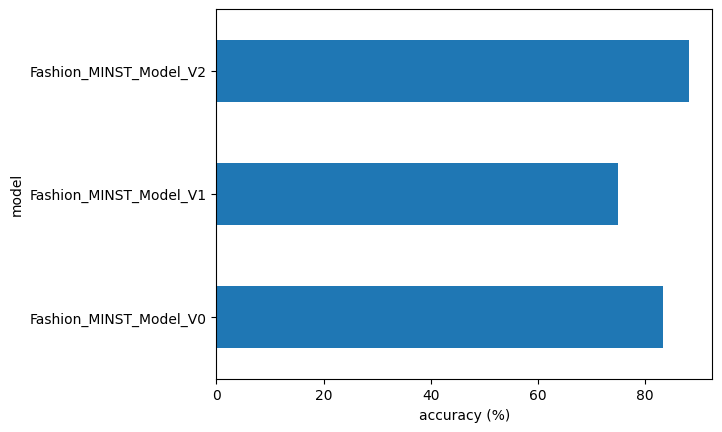

In [52]:
# Visualize model accuracies
# CNN should show clear improvement over linear models
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

## Part 6: Making Predictions on Test Samples

In [53]:
# Function to make predictions on a list of samples
def make_predictions(
    model: torch.nn.Module,
    data: list,
    device: torch.device = device
):
    """
    Make predictions on a list of samples.
    
    Returns:
        Tensor of prediction probabilities for each sample
    """
    pred_probs = []
    model.to(device)
    model.eval()

    with torch.inference_mode():
        
        for sample in data:

            # Prepare sample: add batch dimension and move to device
            sample = torch.unsqueeze(sample, dim=0).to(device)

            # Forward pass (get raw logits)
            pred_logit = model(sample)

            # Convert logits to probabilities using softmax
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            # Move to CPU for further processing
            pred_probs.append(pred_prob.cpu())

    # Stack list of tensors into a single tensor
    return torch.stack(pred_probs)

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 0 (T-shirt/top)


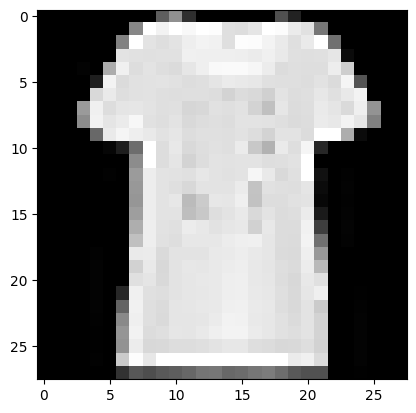

In [54]:
# Get random test samples for prediction demonstration
import random
random.seed(96)

test_samples = []
test_labels = []

# Sample 9 random images from test set
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View first test sample
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

plt.imshow(test_samples[0].squeeze(), cmap="grey")

In [55]:
# Make predictions on test samples using CNN (model_2)
pred_probs = make_predictions(
    model=model_2,
    data=test_samples
)

# Convert prediction probabilities to class labels
# argmax gets the index of the highest probability (the predicted class)
pred_classes = pred_probs.argmax(dim=1)

# Compare predictions to true labels
print(test_labels)
print(pred_classes)

[0, 6, 9, 8, 0, 5, 0, 4, 9]
tensor([0, 2, 9, 8, 0, 5, 0, 4, 9])


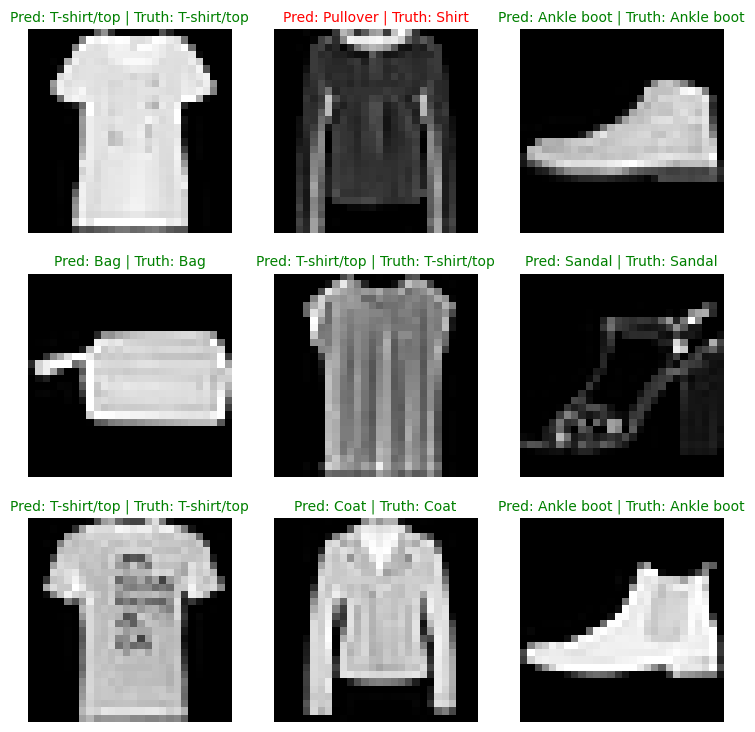

In [56]:
# Visualize predictions vs ground truth
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
    # Create subplot
    plt.subplot(nrows, ncols, i+1)

    # Plot the image
    plt.imshow(sample.squeeze(), cmap="gray")

    # Get prediction label (text form)
    pred_label = class_names[pred_classes[i]]

    # Get ground truth label (text form)
    truth_label = class_names[test_labels[i]]

    # Create title showing prediction vs truth
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    
    # Color code title: green if correct, red if wrong
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")  # Green for correct
    else:
        plt.title(title_text, fontsize=10, c="r")  # Red for incorrect
    
    plt.axis(False)

## Part 7: Confusion Matrix

A confusion matrix shows which classes the model confuses with each other.

In [57]:
# Make predictions on entire test set
y_preds = []
model_2.eval()

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        # Send data to device
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        y_logit = model_2(X)
        
        # Convert: logits -> probabilities -> prediction labels
        # Note: softmax on dim=1 (class dimension), not dim=0 (batch dimension)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
        
        # Move predictions to CPU
        y_preds.append(y_pred.cpu())

# Concatenate list of predictions into single tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions: 100%|██████████| 313/313 [00:01<00:00, 193.39it/s]


In [ ]:
# Install required libraries if not present
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

In [59]:
# Verify mlxtend version
import mlxtend 
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19  # Should be 0.19.0 or higher

0.24.0


In [ ]:
# Create and plot confusion matrix
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion matrix
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')

# Compute confusion matrix by comparing predictions to ground truth
confmat_tensor = confmat(
    preds=y_pred_tensor,
    target=test_data.targets
)

# Plot the confusion matrix
# Diagonal = correct predictions
# Off-diagonal = misclassifications
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),  # Convert to NumPy for matplotlib
    class_names=class_names,  # Label rows and columns
    figsize=(10, 7)
)

## Part 8: Saving and Loading Models

In [ ]:
from pathlib import Path

In [ ]:
# Create directory for saving models
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(
    parents=True,  # Create parent directories if needed
    exist_ok=True  # Don't error if directory already exists
)

In [ ]:
# Save the trained CNN model
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save model state dict (only the learned parameters)
# This is more portable than saving the entire model
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(
    obj=model_2.state_dict(),  # Save only parameters, not model structure
    f=MODEL_SAVE_PATH
)

In [ ]:
# Load the saved model
# Step 1: Create a new instance of the model class
# IMPORTANT: Architecture must match the saved model exactly!
loaded_model_2 = Fashion_MINST_Model_V2(
    input_shape=1,
    hidden_units=10,  # Must match saved model
    output_shape=10
)

# Step 2: Load the saved parameters into the new model
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Step 3: Move to device
loaded_model_2 = loaded_model_2.to(device)

In [ ]:
# Evaluate loaded model to verify it works correctly
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

In [ ]:
# Compare with original model results
# Should be identical or very close
model_2_results

In [ ]:
# Verify results are close (accounting for floating-point precision)
torch.isclose(
    torch.tensor(model_2_results["model_loss"]),
    torch.tensor(loaded_model_2_results["model_loss"]),
    atol=1e-08,  # Absolute tolerance
    rtol=0.0001  # Relative tolerance
)